In [1]:
import torch
import torch.nn as nn 
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
X,y = load_iris(return_X_y=True)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    X,y ,test_size=0.2, random_state = 42
)

In [3]:
class IrisNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4,16)
        self.fc2 = nn.Linear(16,3)

    def forward(self,x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)    

In [4]:
model = IrisNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [5]:
for epoch in range(500):
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    if epoch % 100 ==0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.2541
Epoch 100, Loss: 0.0873
Epoch 200, Loss: 0.0531
Epoch 300, Loss: 0.0470
Epoch 400, Loss: 0.0438


In [6]:
with torch.no_grad():
    outputs = model(X_test)
    preds = torch.argmax(outputs, dim=1)
    accuracy = (preds == y_test).float().mean()

accuracy.item()    

1.0

In [7]:
nn.Dropout(p=0.5)


Dropout(p=0.5, inplace=False)

In [9]:
optim.Adam(model.parameters(), lr=0.01,weight_decay=1e-4)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0.0001
)

In [10]:
X_train,X_val,y_train,y_val = train_test_split(
    X_train,y_train,test_size=0.2,random_state=42
)

In [11]:
class IrisNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4,32)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(32,3)


    def forward(self,x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


In [12]:
train_losses = []
val_losses = []

for epoch in range(300):

    model.train()
    outputs = model(X_train)
    loss = criterion(outputs,y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())


    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs,y_val)
        val_losses.append(val_loss.item())

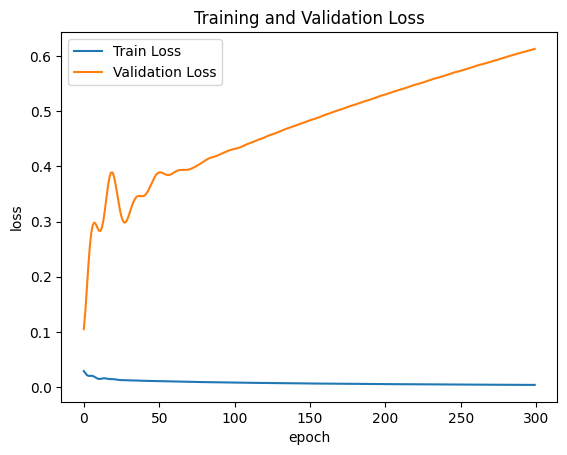

In [13]:
import matplotlib.pyplot as plt

plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training and Validation Loss")
plt.show()